# EDA  Analysis on the Angiogram Image Dataset

## SECTION 0 — Setup & Imports

In [1]:
# ====== SECTION 0: SETUP & IMPORTS ======
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import random

sns.set(style="whitegrid")


## SECTION 1 — Load ARCADE Dataset Structure

In [2]:
# ====== SECTION 1: LOAD DATASET STRUCTURE ======

# Change this path to your ARCADE dataset folder
arcade_path = Path("C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/Angiogram Images/syntax/train/images")

image_paths = list(arcade_path.rglob("*.png")) + list(arcade_path.rglob("*.jpg"))

print(f"Total images found: {len(image_paths)}")

# Display first 10 example paths
image_paths[:10]


Total images found: 1000


[WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/Angiogram Images/syntax/train/images/1.png'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/Angiogram Images/syntax/train/images/10.png'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/Angiogram Images/syntax/train/images/100.png'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/Angiogram Images/syntax/train/images/1000.png'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/Angiogram Images/syntax/train/images/101.png'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/Angiogram Images/syntax/train/images/102.png'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science Group Project/Angiogram Images/syntax/train/images/103.png'),
 WindowsPath('C:/Users/User/Documents/IIT Stage 2/CM2603  Data Science 

## SECTION 2 — Display Random Sample Images

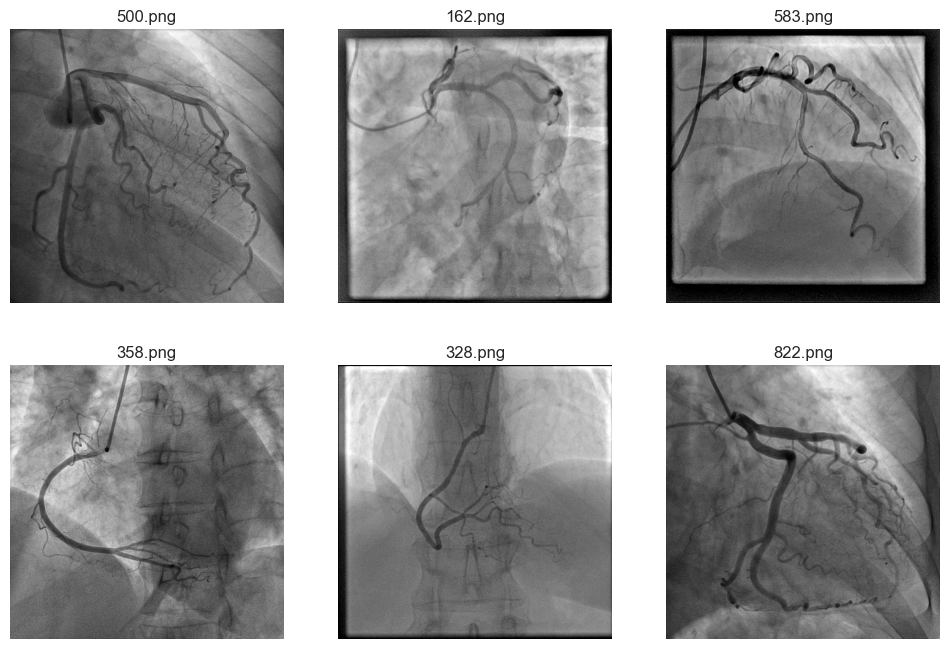

In [3]:
# ====== SECTION 2: VISUAL SAMPLE IMAGES ======

sample_paths = random.sample(image_paths, 6)

plt.figure(figsize=(12, 8))
for i, p in enumerate(sample_paths):
    img = cv2.imread(str(p), 0)
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap="gray")
    plt.title(p.name)
    plt.axis("off")
plt.show()


## SECTION 3 — Image Resolution Analysis

In [8]:
# ====== SECTION 3: RESOLUTION ANALYSIS ======

res_data = []

for p in tqdm(image_paths):
    img = cv2.imread(str(p))
    if img is None:
        continue
    h, w = img.shape[:2]
    res_data.append([w, h, p.parent.name])

df_res = pd.DataFrame(res_data, columns=["width", "height", "folder"])
df_res.head()


100%|██████████| 1000/1000 [00:05<00:00, 197.05it/s]


,width,height,folder
0,512,512,images
1,512,512,images
2,512,512,images
3,512,512,images
4,512,512,images


Resolution Plots:

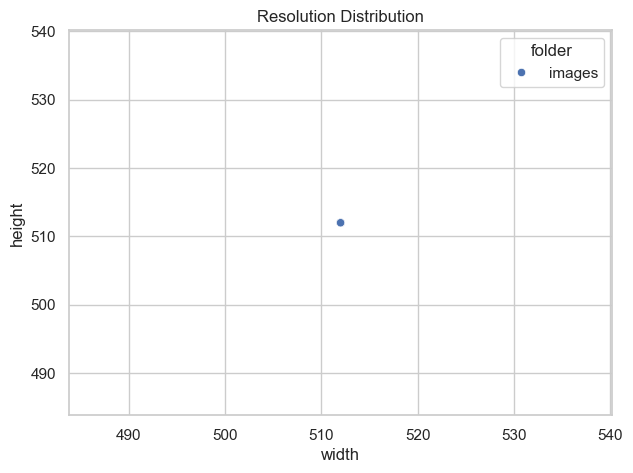

,width,height
count,1000.0,1000.0
mean,512.0,512.0
std,0.0,0.0
min,512.0,512.0
25%,512.0,512.0
50%,512.0,512.0
75%,512.0,512.0
max,512.0,512.0


In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_res, x="width", y="height", hue="folder")
plt.title("Resolution Distribution")
plt.show()

df_res[["width", "height"]].describe()


## SECTION 4 — Brightness (Mean Intensity) Analysis

In [10]:
# ====== SECTION 4: BRIGHTNESS ANALYSIS ======

brightness_info = []

for p in tqdm(image_paths):
    img = cv2.imread(str(p), 0)
    if img is None: continue
    brightness_info.append([img.mean(), p.parent.name])

df_brightness = pd.DataFrame(brightness_info, columns=["brightness", "folder"])
df_brightness.head()


100%|██████████| 1000/1000 [00:03<00:00, 264.81it/s]


,brightness,folder
0,114.085621,images
1,98.832672,images
2,117.033005,images
3,110.167332,images
4,128.854443,images


Plot brightness distribution:

C:\Users\User\AppData\Local\Temp\ipykernel_1512\2374196903.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_brightness, y="folder", x="brightness", palette="Set2")


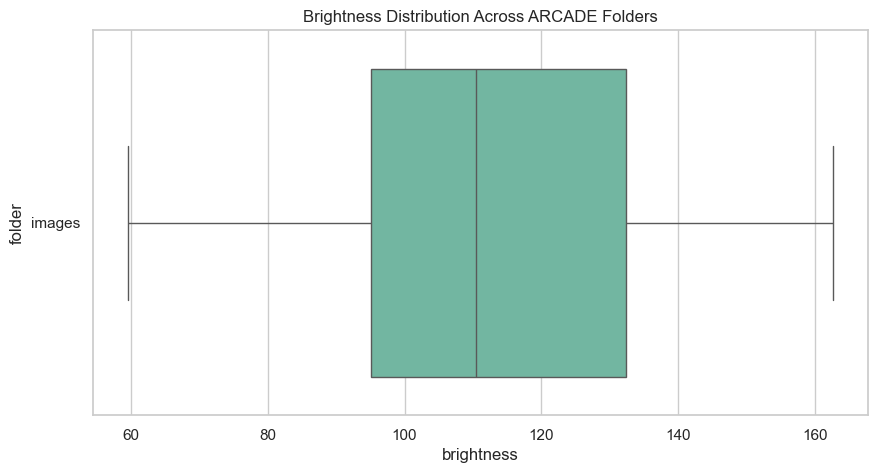

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_brightness, y="folder", x="brightness", palette="Set2")
plt.title("Brightness Distribution Across ARCADE Folders")
plt.show()


## SECTION 5 — Contrast (Intensity Standard Deviation) Analysis

In [12]:
# ====== SECTION 5: CONTRAST ANALYSIS ======

contrast_info = []

for p in tqdm(image_paths):
    img = cv2.imread(str(p), 0)
    if img is None: continue
    contrast_info.append([img.std(), p.parent.name])

df_contrast = pd.DataFrame(contrast_info, columns=["contrast", "folder"])
df_contrast.head()


100%|██████████| 1000/1000 [00:05<00:00, 187.03it/s]


,contrast,folder
0,34.876722,images
1,22.534339,images
2,37.696870,images
3,54.162489,images
4,39.311319,images


Plot contrast distribution:

C:\Users\User\AppData\Local\Temp\ipykernel_1512\1285598977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_contrast, y="folder", x="contrast", palette="viridis")


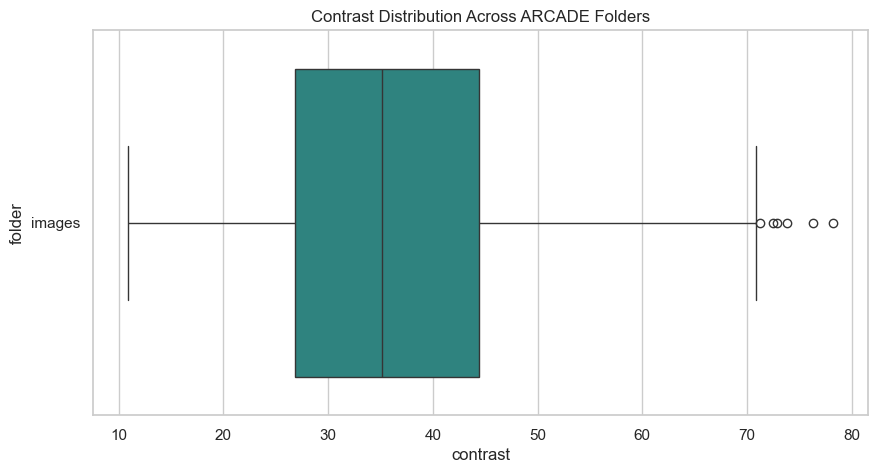

In [13]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_contrast, y="folder", x="contrast", palette="viridis")
plt.title("Contrast Distribution Across ARCADE Folders")
plt.show()


## SECTION 6 — Noise (Sharpness) Analysis Using Laplacian Variance

In [14]:
# ====== SECTION 6: NOISE / SHARPNESS ANALYSIS ======

def laplacian_variance(img):
    return cv2.Laplacian(img, cv2.CV_64F).var()

noise_info = []

for p in tqdm(image_paths):
    img = cv2.imread(str(p), 0)
    if img is None: continue
    noise_info.append([laplacian_variance(img), p.parent.name])

df_noise = pd.DataFrame(noise_info, columns=["sharpness", "folder"])
df_noise.head()


100%|██████████| 1000/1000 [00:06<00:00, 148.51it/s]


,sharpness,folder
0,234.280543,images
1,193.432400,images
2,276.617123,images
3,691.129062,images
4,285.536995,images


Plot sharpness

C:\Users\User\AppData\Local\Temp\ipykernel_1512\1005320491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_noise, y="folder", x="sharpness", palette="coolwarm")


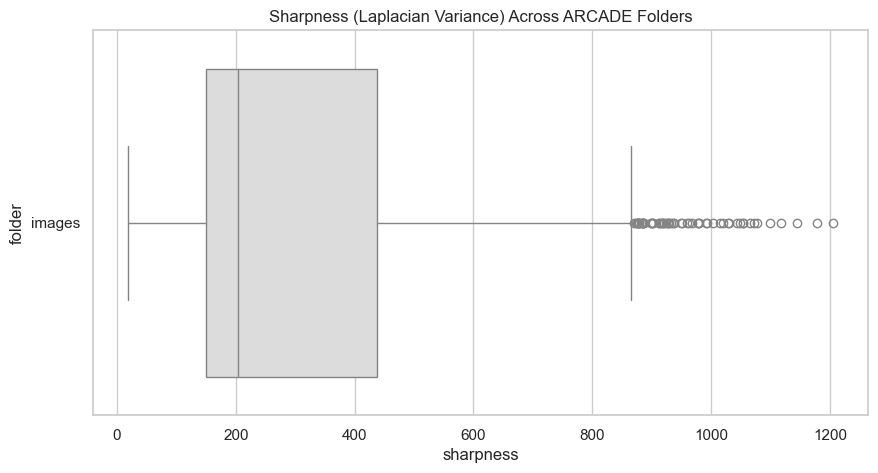

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_noise, y="folder", x="sharpness", palette="coolwarm")
plt.title("Sharpness (Laplacian Variance) Across ARCADE Folders")
plt.show()


## SECTION 7 — Pixel Histogram Visualization

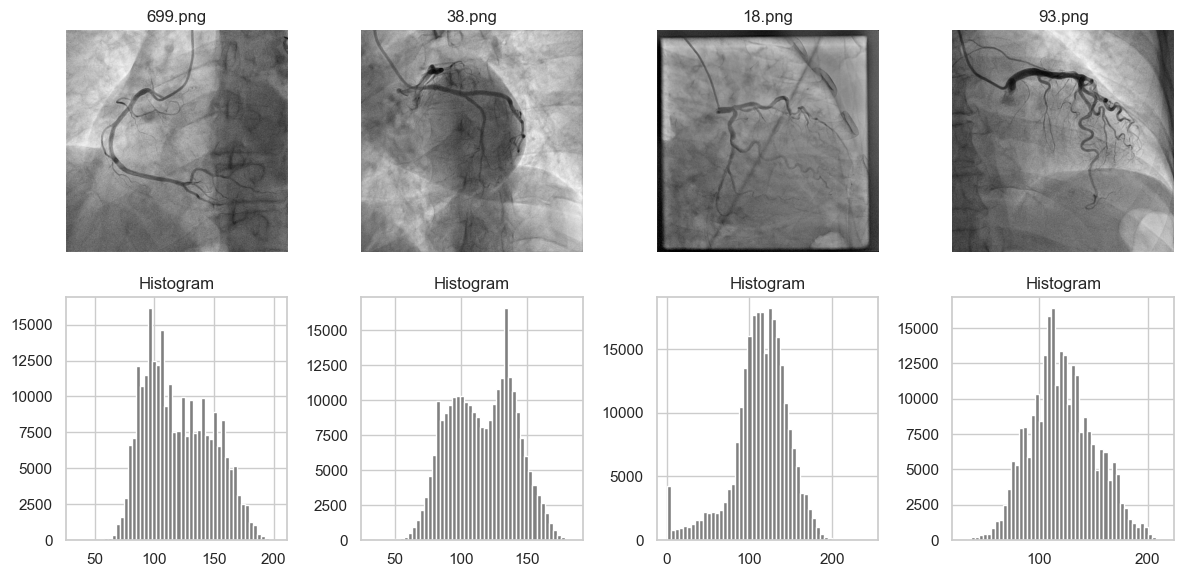

In [16]:
# ====== SECTION 7: PIXEL HISTOGRAM ANALYSIS ======

sample_paths = random.sample(image_paths, 4)

plt.figure(figsize=(12,6))

for i, p in enumerate(sample_paths):
    img = cv2.imread(str(p), 0)
    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(p.name)
    plt.axis('off')

    plt.subplot(2,4,i+5)
    plt.hist(img.ravel(), bins=50, color='gray')
    plt.title("Histogram")

plt.tight_layout()
plt.show()


## SECTION 8 — Vessel Visibility Score (Edge-Based)

In [18]:
# ====== SECTION 8: VESSEL VISIBILITY SCORE ======

visibility_info = []

for p in tqdm(image_paths):
    img = cv2.imread(str(p), 0)
    if img is None: continue

    edges = cv2.Canny(img, 50, 150)
    visibility_info.append([edges.sum(), p.parent.name])

df_visibility = pd.DataFrame(visibility_info, columns=["vessel_score", "folder"])
df_visibility.head(10)


100%|██████████| 1000/1000 [00:05<00:00, 168.85it/s]


,vessel_score,folder
0,1138320,images
1,388365,images
2,1582275,images
3,5625045,images
4,1705950,images
5,2207025,images
6,2194275,images
7,120870,images
8,5236935,images
9,2489055,images


Plot vessel visibility

C:\Users\User\AppData\Local\Temp\ipykernel_1512\1684772374.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_visibility, y="folder", x="vessel_score", palette="magma")


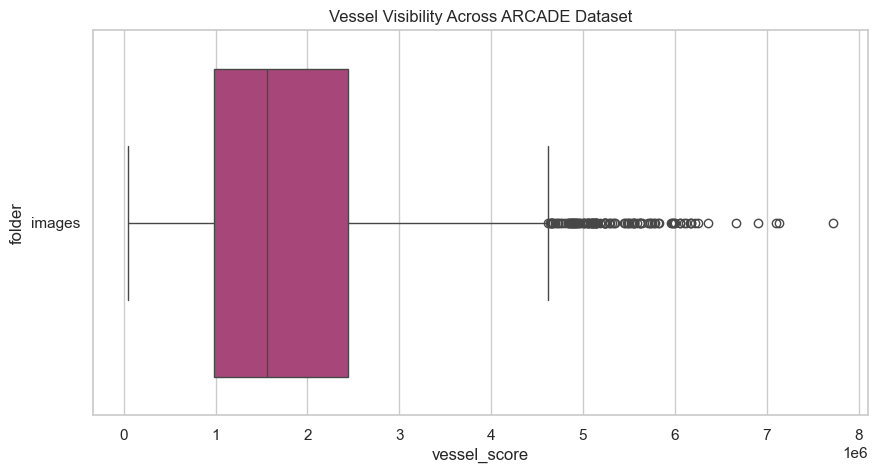

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_visibility, y="folder", x="vessel_score", palette="magma")
plt.title("Vessel Visibility Across ARCADE Dataset")
plt.show()


## SECTION 9 — Outlier Detection

In [25]:
# ====== SECTION 9: OUTLIER DETECTION ======

q1 = df_brightness["brightness"].quantile(0.25)
q3 = df_brightness["brightness"].quantile(0.75)
iqr = q3 - q1

low_thresh = q1 - 1.5 * iqr
high_thresh = q3 + 1.5 * iqr

outliers = df_brightness[(df_brightness["brightness"] < low_thresh) |
                         (df_brightness["brightness"] > high_thresh)]

outliers.head()


,brightness,folder
